<a href="https://colab.research.google.com/github/parthkumarbiswas2000/Skill-Morph/blob/Skill_Morph/Introduction_to_ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In [2]:
print("Welcome to Cancer Detection with Partho!")
print("We will build a ML_Based Doctor to detect breast cancer!")

Welcome to Cancer Detection with Partho!
We will build a ML_Based Doctor to detect breast cancer!


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
    )
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

In [4]:
print("Reading the real cancer dataset...")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/Datasets_SkillMorph/Breast_Cancer_Wisconsin_Dataset.csv')

print(f"Data Update Done! We have data from {len(data)} real patients")
print(f"Each patient has {len(data.columns)-2} medical measurements")

# Show first few patients
print("\n First 10 patients in our dataset:")
print(data[['id', 'diagnosis', 'perimeter_mean', 'smoothness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean','radius_se', 'texture_se','perimeter_se']].head(10))

# Understand diagnosis column
print(f"\nUnderstanding Diagnosis:")
diagnosis_counts = data['diagnosis'].value_counts()
print(f"M (Malignant = Dangerous Cancer):  {diagnosis_counts['M']} patients")
print(f"B (Benign = Harmless Cancer):      {diagnosis_counts['B']} patients")
print(f"Total patients:                    {len(data)} patients")

Reading the real cancer dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Update Done! We have data from 569 real patients
Each patient has 31 medical measurements

 First 10 patients in our dataset:
         id diagnosis  perimeter_mean  smoothness_mean  concavity_mean  \
0    842302         M          122.80          0.11840         0.30010   
1    842517         M          132.90          0.08474         0.08690   
2  84300903         M          130.00          0.10960         0.19740   
3  84348301         M           77.58          0.14250         0.24140   
4  84358402         M          135.10          0.10030         0.19800   
5    843786         M           82.57          0.12780         0.15780   
6    844359         M          119.60          0.09463         0.11270   
7  84458202         M           90.20          0.11890         0.09366   
8    844981         M           87.50  

# Data Preparation

In [5]:
print("Computers only understand numbers, not letters!")
print("Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)")

# Convert diagnosis to number
data['diagnosis_number'] = data['diagnosis'].map({'M': 1, 'B': 0})
print("Conversion Done!")

important_features = ['radius_mean',
                      'texture_mean',
                      'perimeter_mean',
                      'area_mean',
                      'smoothness_mean',
                      'compactness_mean',
                      'concavity_mean',
                      'concave points_mean',
                      'symmetry_mean',
                      'fractal_dimension_mean']
# Create simple dataset
X = data[important_features]  # Patient measurements
y = data['diagnosis_number']  # Malignant (1) or Benign (0)

print(f"\nData prepared:")
print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")

Computers only understand numbers, not letters!
Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)
Conversion Done!

Data prepared:
X (measurements): (569, 10)
y (diagnosis): (569,)


# Train and Test data split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test)} patients (computer will be tested on these)")

# Show some training examples
print(f"\n Training Examples (Computer learns from these):")
print(X_train.head())

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)

 Training Examples (Computer learns from these):
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
412        9.397         21.68           59.75      268.8          0.07969   
461       27.420         26.27          186.90     2501.0          0.10840   
532       13.680         16.33           87.76      575.5          0.09277   
495       14.870         20.21           96.12      680.9          0.09587   
13        15.850         23.95          103.70      782.7          0.08401   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
412           0.06053         0.03735             0.005128         0.1274   
461           0.19880         0.36350             0.168900         0.2061   
532           0.07255         0.01752             0.018800         0.1631   
495           0.08345         0.06824             0.049510 

# Decision Tree Classifier Model Training

In [7]:
ml_doctor = DecisionTreeClassifier(
    max_depth=9,
    random_state=20
)
print("Teaching ML doctor with training data...")
ml_doctor.fit(X_train, y_train)
print("Teaching Done!")

Teaching ML doctor with training data...
Teaching Done!


# Test ML Doctor

In [8]:
print("Now let's see how good ML doctor is...")
print("Testing on patients it has NEVER seen before!")

# Make predictions
predictions = ml_doctor.predict(X_test)
prediction_probabilities = ml_doctor.predict_proba(X_test)[:, 1]  # Probability of malignant cancer (class 1)
print("ML doctor made predictions for all test patients!")
print(f"Note: We also got probability scores (confidence levels) for each prediction!")

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nML Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

if accuracy > 0.95:
    print("EXCELLENT! Our ML doctor is very accurate!")
elif accuracy > 0.90:
    print("GOOD! Our ML doctor performs well!")
elif accuracy > 0.80:
    print("OK! Our ML doctor is decent!")
else:
    print("Needs improvement...")

# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("Patient | Actual      | ML Predicted | Confidence | Correct?")
print("-" * 70)

for i in range(10):
    actual = "Malignant" if y_test.iloc[i] == 1 else "Benign"
    predicted = "Malignant" if predictions[i] == 1 else "Benign"
    confidence = prediction_probabilities[i] * 100 if predictions[i] == 1 else (1 - prediction_probabilities[i]) * 100
    correct = "✅" if y_test.iloc[i] == predictions[i] else "❌"
    print(f"{i+1:7} | {actual:11} | {predicted:17} | {confidence:8.1f}%  | {correct}")



Now let's see how good ML doctor is...
Testing on patients it has NEVER seen before!
ML doctor made predictions for all test patients!
Note: We also got probability scores (confidence levels) for each prediction!

ML Doctor Accuracy: 0.930 (93.0%)
GOOD! Our ML doctor performs well!

Let's check some predictions with confidence:
Patient | Actual      | ML Predicted | Confidence | Correct?
----------------------------------------------------------------------
      1 | Benign      | Benign            |    100.0%  | ✅
      2 | Malignant   | Benign            |    100.0%  | ❌
      3 | Malignant   | Malignant         |    100.0%  | ✅
      4 | Benign      | Benign            |    100.0%  | ✅
      5 | Malignant   | Malignant         |    100.0%  | ✅
      6 | Malignant   | Malignant         |    100.0%  | ✅
      7 | Malignant   | Malignant         |    100.0%  | ✅
      8 | Benign      | Benign            |    100.0%  | ✅
      9 | Benign      | Malignant         |    100.0%  | ❌
     10

# Confusion Matrix

Confusion Matrix (Mistake Analysis):
[[61  5]
 [ 3 45]]

How to read Confusion Matrix:

                 Skill Morph Predicted
              Benign   Malignant
Real Benign     61        5   ← 5 False Alarms (predicted malignant but was benign)
Real Malignant  3        45   ← 3 Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: 106
❌ Wrong Predictions: 8

⚠️ DANGER: Missing malignant cancer (3 cases) is more dangerous than false alarms (5 cases)



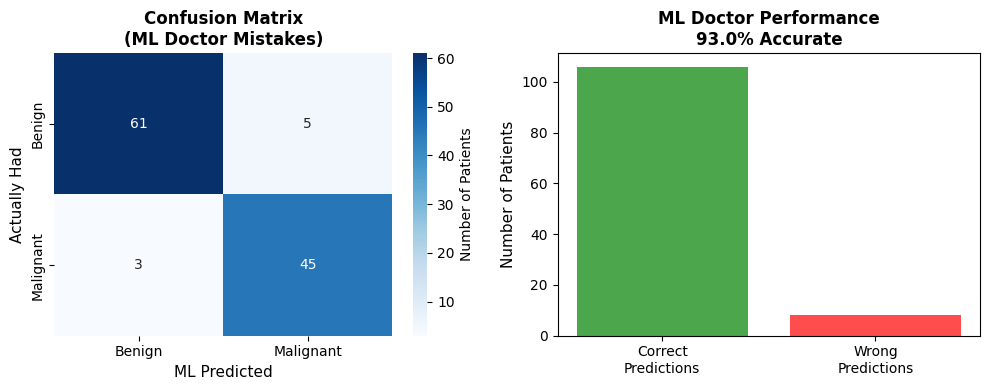

In [9]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix (Mistake Analysis):")
print(cm)

print("\nHow to read Confusion Matrix:")
print(f"""
                 Skill Morph Predicted
              Benign   Malignant
Real Benign     {cm[0,0]}        {cm[0,1]}   ← {cm[0,1]} False Alarms (predicted malignant but was benign)
Real Malignant  {cm[1,0]}        {cm[1,1]}   ← {cm[1,0]} Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: {cm[0,0] + cm[1,1]}
❌ Wrong Predictions: {cm[0,1] + cm[1,0]}

⚠️ DANGER: Missing malignant cancer ({cm[1,0]} cases) is more dangerous than false alarms ({cm[0,1]} cases)
""")

# Create beautiful confusion matrix plot
plt.figure(figsize=(10, 4))

# Confusion Matrix Plot
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Number of Patients'})
plt.title('Confusion Matrix\n(ML Doctor Mistakes)', fontweight='bold', fontsize=12)
plt.xlabel('ML Predicted', fontsize=11)
plt.ylabel('Actually Had', fontsize=11)

# Accuracy visualization
plt.subplot(1, 2, 2)
categories = ['Correct\nPredictions', 'Wrong\nPredictions']
values = [cm[0,0] + cm[1,1], cm[0,1] + cm[1,0]]
colors = ['green', 'red']
plt.bar(categories, values, color=colors, alpha=0.7)
plt.title(f'ML Doctor Performance\n{accuracy*100:.1f}% Accurate', fontweight='bold', fontsize=12)
plt.ylabel('Number of Patients', fontsize=11)

plt.tight_layout()
plt.show()

# Detailed Visualization

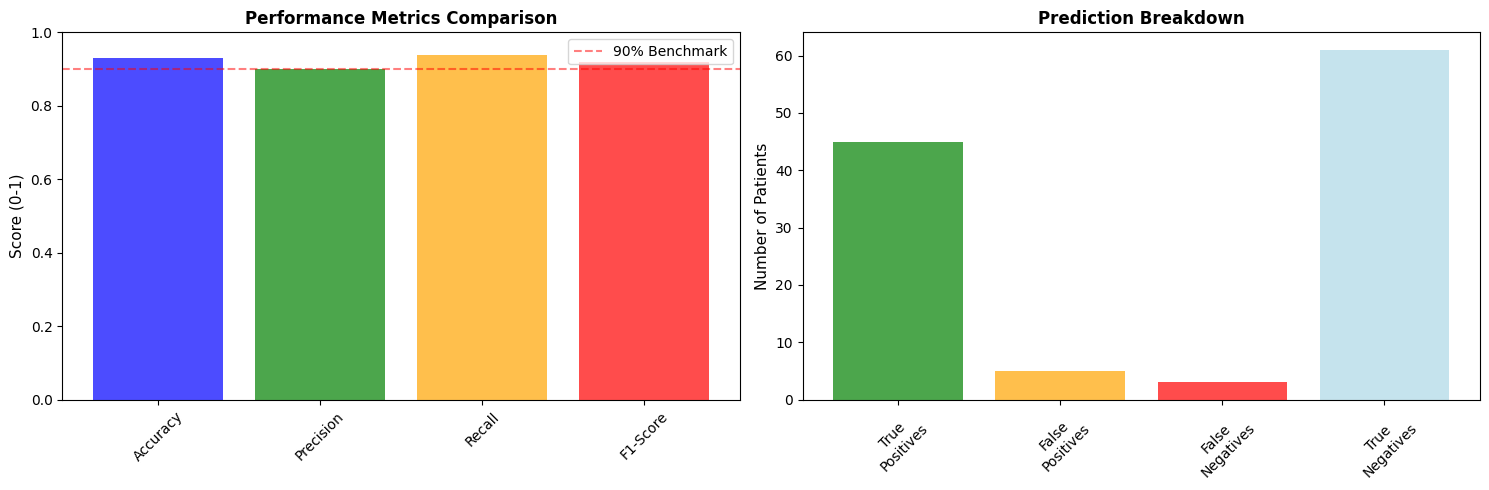

In [10]:
# Calculate detailed metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)


# Create detailed metrics visualization
plt.figure(figsize=(15, 5))

# Subplot 1: Metrics comparison
plt.subplot(1, 2, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['blue', 'green', 'orange', 'red']
bars = plt.bar(metrics, values, color=colors, alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics Comparison', fontweight='bold', fontsize=12)
plt.ylabel('Score (0-1)', fontsize=11)


# Add benchmark line
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% Benchmark')
plt.legend()
plt.xticks(rotation=45)



# Subplot 2: Precision vs Recall visualization
plt.subplot(1, 2, 2)
# Create a simple precision-recall visualization
categories = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
tp, fp, fn, tn = cm[1,1], cm[0,1], cm[1,0], cm[0,0]
counts = [tp, fp, fn, tn]
colors_pr = ['green', 'orange', 'red', 'lightblue']
bars_pr = plt.bar(categories, counts, color=colors_pr, alpha=0.7)
plt.title('Prediction Breakdown', fontweight='bold', fontsize=12)
plt.ylabel('Number of Patients', fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ROC & AUC Curve

OUR ML AUC SCORE:
AUC Score: 0.9309 (93.09%)


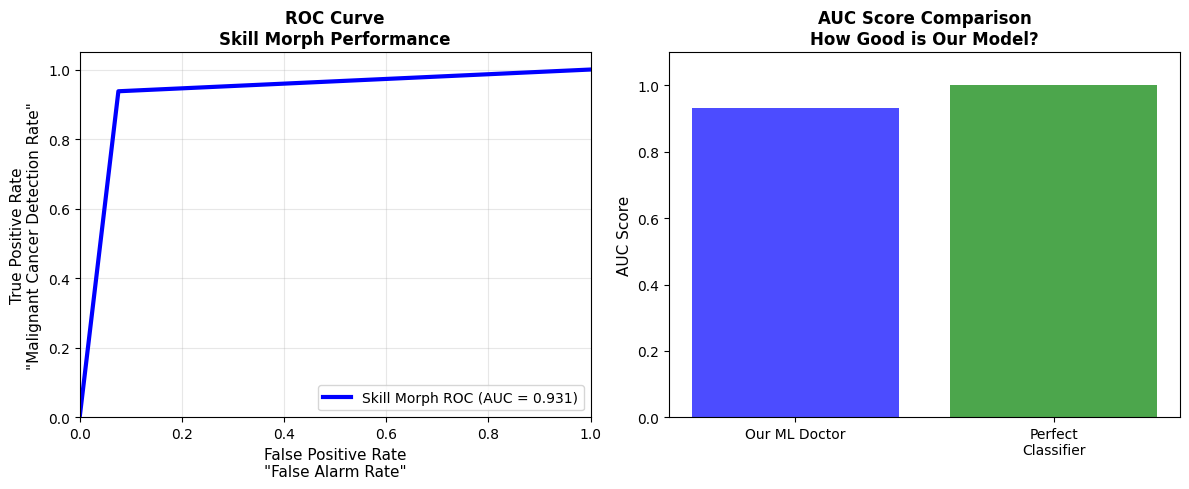

In [11]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, prediction_probabilities)
auc_score = roc_auc_score(y_test, prediction_probabilities)

print(f"OUR ML AUC SCORE:")
print(f"{'='*40}")
print(f"AUC Score: {auc_score:.4f} ({auc_score*100:.2f}%)")

# Create comprehensive ROC visualization
plt.figure(figsize=(12, 5))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=3, label=f'Skill Morph ROC (AUC = {auc_score:.3f})')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate\n"False Alarm Rate"', fontsize=11)
plt.ylabel('True Positive Rate\n"Malignant Cancer Detection Rate"', fontsize=11)
plt.title('ROC Curve\nSkill Morph Performance', fontweight='bold', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: AUC Comparison
plt.subplot(1, 2, 2)
model_names = ['Our ML Doctor', 'Perfect\nClassifier']
auc_scores = [auc_score, 1.0]
colors_auc = ['blue', 'green']
bars_auc = plt.bar(model_names, auc_scores, color=colors_auc, alpha=0.7)

plt.ylim(0, 1.1)
plt.ylabel('AUC Score', fontsize=11)
plt.title('AUC Score Comparison\nHow Good is Our Model?', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
